<a href="https://colab.research.google.com/github/Stanitaa/Asos-Python-analysis/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('products_asos.csv', on_bad_lines="skip")
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df= df.dropna(subset=['price'])
print(f"data loaded: {len(df)}rows")
df.head()



data loaded: 18378rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


# New section

In [ ]:
df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by ' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return 'unknown'
  return 'unknown'

df['brand_raw'] = df['description'].apply(get_brand)

In [ ]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw,Brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look


In [ ]:
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >5].index

df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))



Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [ ]:
# 1. Function to Analyze stockouts
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0

  # split "UK 6, UK 8 - Out of stock" into list
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  #Count how many items are out if stock
  out_of_stock_count = size_str.count('Out of stock')

  #Calculate Rate(0.0 to 1.0)
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count']

cols = ['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']

print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


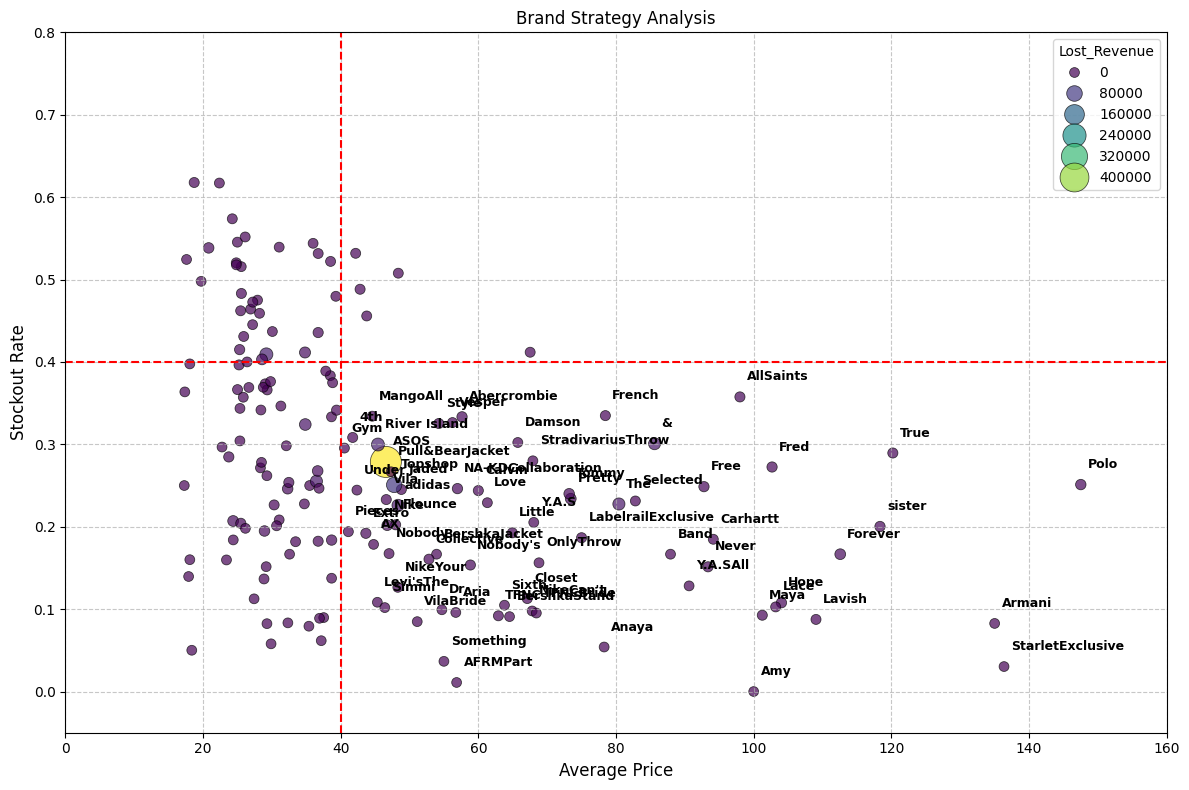

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',  # Changed from 'sum' to 'mean'
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size= 'Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7,
    hue='Lost_Revenue',
    palette='viridis',
    edgecolor='k',
    )
winners = brand_strategy[
    (brand_strategy['price'] >40) &
    (brand_strategy['Stockout_Rate'] <0.4)
]
# Iterate over the top 5 brands by count and add their labels
for brand_name in top_5_brands_by_count:
  brand_info = brand_strategy[brand_strategy['Brand'] == brand_name]
  if not brand_info.empty:
      plt.text(
          brand_info['price'].item() + 1, # Offset x-position slightly
          brand_info['Stockout_Rate'].item() + 0.02, # Offset y-position slightly upwards
          brand_name,
          fontsize=9, # Adjust font size for labels
          weight='bold' # Make labels bold
      )

plt.title('Brand Strategy Analysis', fontsize=12)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Stockout Rate', fontsize=12)
plt.axvline(x=40, color='red', linestyle='--', linewidth=1.5)
plt.axhline(y=0.4, color='red', linestyle='--', linewidth=1.5)

# Set explicit axis limits for cleaner display
plt.xlim(0, 160) # Adjust based on min/max price observed (17.28 to 147.51)
plt.ylim(-0.05, 0.8) # Stockout rate is between 0 and 0.8 (user specified)

plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
top_5_brands_by_count = df_clean['Brand'].value_counts().head(5).index.tolist()

print("Winner status for top 5 brands by product count:")
for brand_name in top_5_brands_by_count:
    brand_data = brand_strategy[brand_strategy['Brand'] == brand_name]
    if not brand_data.empty:
        is_winner = ((brand_data['price'] > 40) & (brand_data['Stockout_Rate'] < 0.4)).item()
        print(f"- {brand_name}: {'Winner' if is_winner else 'Not a Winner'} (Price: {brand_data['price'].item():.2f}, Stockout Rate: {brand_data['Stockout_Rate'].item():.2f})")
    else:
        print(f"- {brand_name}: Not found in brand_strategy (possibly filtered out by product count > 10)")

Winner status for top 5 brands by product count:
- ASOS: Winner (Price: 46.57, Stockout Rate: 0.28)
- Topshop: Winner (Price: 47.77, Stockout Rate: 0.25)
- New Look: Not a Winner (Price: 29.21, Stockout Rate: 0.41)
- River Island: Winner (Price: 45.42, Stockout Rate: 0.30)
- Miss Selfridge: Not a Winner (Price: 36.48, Stockout Rate: 0.26)


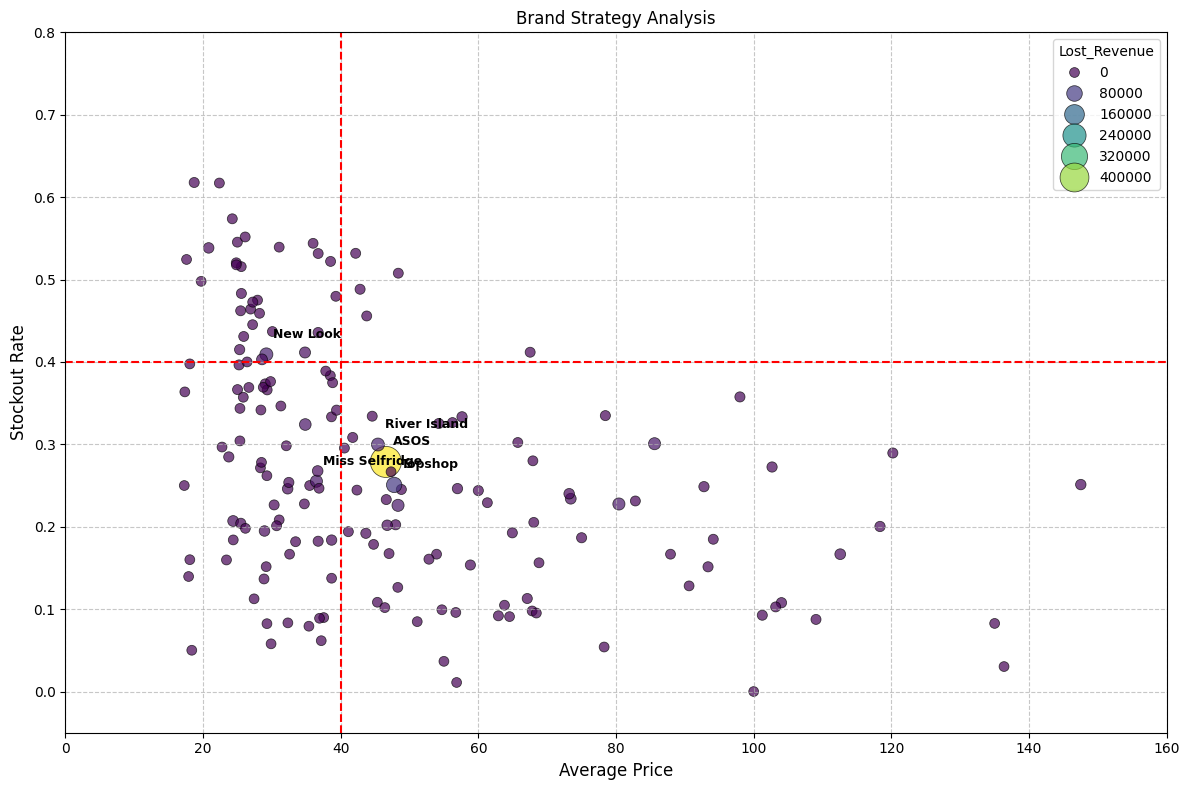

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',  # Changed from 'sum' to 'mean'
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size= 'Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7,
    hue='Lost_Revenue',
    palette='viridis',
    edgecolor='k',
    )

# Iterate over the top 5 brands by count and add their labels
# top_5_brands_by_count should be defined from a previous cell.
# If it's not defined, please run the cell above (115b65eb) first.
if 'top_5_brands_by_count' in locals():
    for brand_name in top_5_brands_by_count:
      brand_info = brand_strategy[brand_strategy['Brand'] == brand_name]
      if not brand_info.empty:
          plt.text(
              brand_info['price'].item() + 1, # Offset x-position slightly
              brand_info['Stockout_Rate'].item() + 0.02, # Offset y-position slightly upwards
              brand_name,
              fontsize=9, # Adjust font size for labels
              weight='bold' # Make labels bold
          )
else:
    print("Warning: 'top_5_brands_by_count' not found. Labels for top 5 brands will not be plotted.")

plt.title('Brand Strategy Analysis', fontsize=12)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Stockout Rate', fontsize=12)
plt.axvline(x=40, color='red', linestyle='--', linewidth=1.5)
plt.axhline(y=0.4, color='red', linestyle='--', linewidth=1.5)

# Set explicit axis limits for cleaner display
plt.xlim(0, 160) # Adjust based on min/max price observed (17.28 to 147.51)
plt.ylim(-0.05, 0.8) # Stockout rate is between 0 and 0.8 (user specified)

plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()